### IPL 2022 Capstone Project


This projects explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performance, and team dynamics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Loading the dataset

df = pd.read_csv('IPL.csv')

In [8]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [5]:
# Basic Information

df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [11]:
# Check the size of rows and columns of the dataset

df.shape
print(f"Your rows are {df.shape[0]} and columns are {df.shape[1]}")

Your rows are 74 and columns are 20


In [10]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

In [ ]:
# Now lets see how many columns have null values in total

df.isnull()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
70,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
71,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [37]:
# Which team wins the most matches
df['match_winner'].value_counts()

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

In [43]:
# df['match_winner'].value_counts().idxmax()  # Use id max for name 
match_win=df['match_winner'].value_counts()  

Text(0.5, 1.0, 'Most Match Winner')

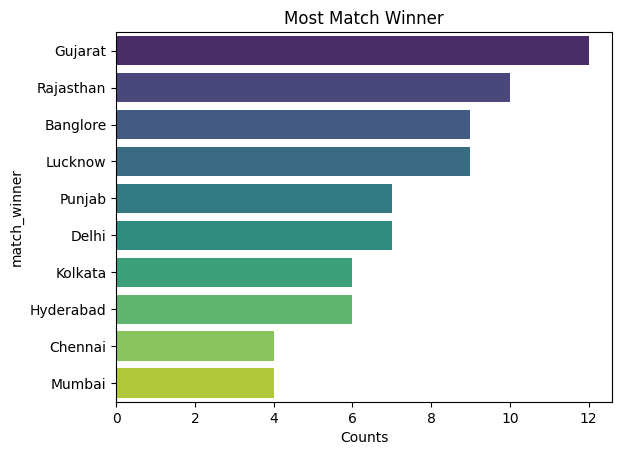

In [49]:
sns.barplot(y=match_win.index,x=match_win.values,palette='viridis')
plt.xlabel('Counts')
plt.title('Most Match Winner')

In [ ]:
# Toss Descision Trends
df.columns
df[['toss_decision','toss_winner']]


,toss_decision,toss_winner
0,Field,Kolkata
1,Field,Delhi
2,Field,Punjab
3,Field,Gujarat
4,Field,Hyderabad
...,...,...
69,Bat,Hyderabad
70,Field,Gujarat
71,Field,Lucknow
72,Field,Rajasthan


In [ ]:
# df['toss_decision'].value_counts().idxmax()
# toss_trend=df['toss_decision'].value_counts()

<Axes: xlabel='toss_decision', ylabel='count'>

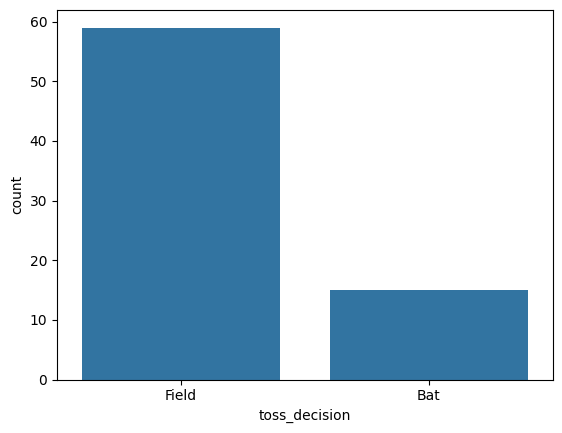

In [63]:
sns.countplot(x=df['toss_decision'])

In [66]:
# Toss Winner V/s Match winner

count=df[df['toss_winner']==df['match_winner']]['match_id'].count()

In [75]:
per=(count*100)/df.shape[0]
print(f"Percentage to wins if they win the toss {per.round(2)}")

Percentage to wins if they win the toss 48.65


Text(0.5, 0, 'Won_by')

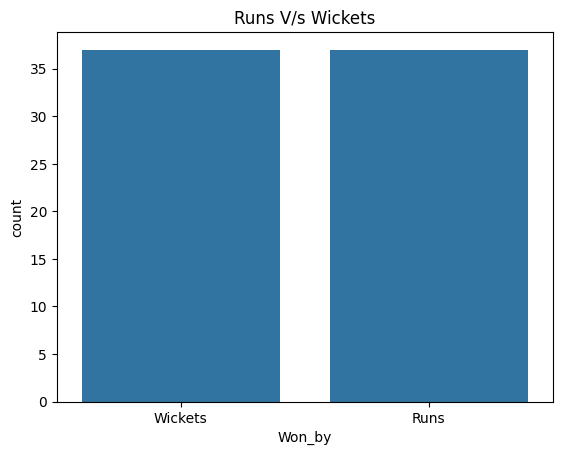

In [85]:
# How do team win? (Runs vs Wickets)
df.head()

won=df['won_by'].value_counts()
# sns.barplot(x=won.index,y=won.values,palette='coolwarm')
sns.countplot(x=df['won_by'])
plt.title('Runs V/s Wickets')
plt.xlabel('Won_by')


### Key Player Performance

In [ ]:
# Most "Player of the Match" Awards

df['player_of_the_match'].value_counts().idxmax()
df['player_of_the_match'].value_counts()

'Kuldeep Yadav'

In [104]:
count=df['player_of_the_match'].value_counts().head(10)
count


player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

Text(0.5, 0, 'Counts')

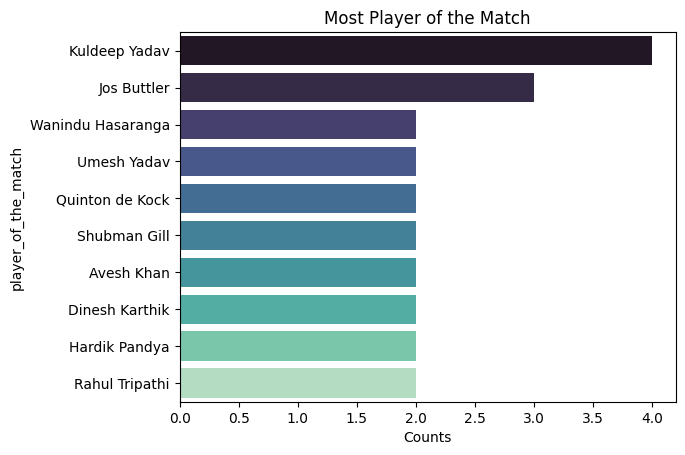

In [109]:
sns.barplot(x=count.values,y=count.index,palette='mako')
plt.title('Most Player of the Match')
plt.xlabel('Counts')

In [114]:
# 2 Top scorers
df['top_scorer'].value_counts().head(2)

top_scorer
Jos Buttler        7
Quinton de Kock    5
Name: count, dtype: int64

In [120]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)

In [121]:
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

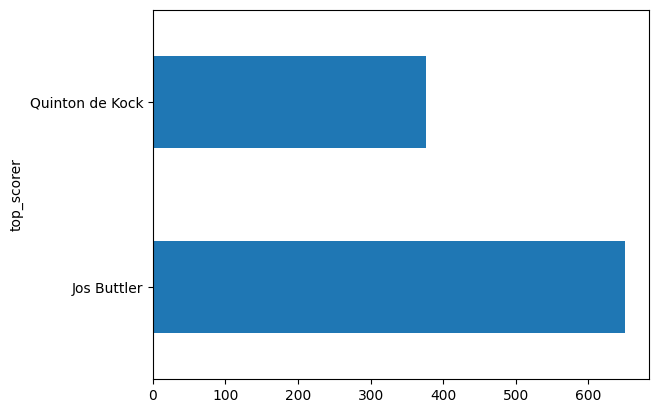

In [123]:
high.plot(kind='barh')

In [124]:
# Best Bowling Figures
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [136]:
df['Highest_wic']=df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['Highest_wic']=df['Highest_wic'].astype(int)
top_bowlers=df.groupby('best_bowling')['Highest_wic'].sum()

<Axes: ylabel='best_bowling'>

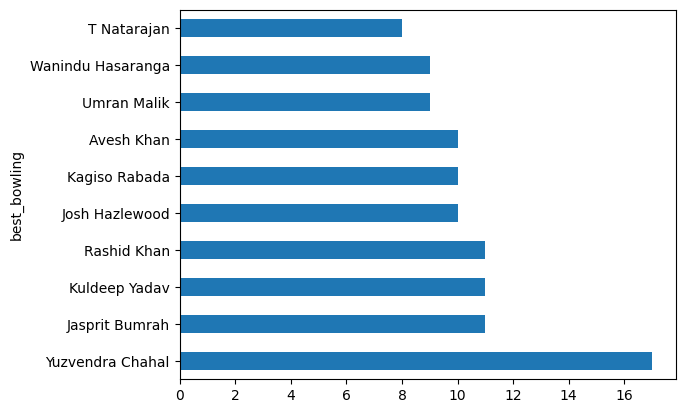

In [147]:
top_bowlers=top_bowlers.sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh')

## Venue Analysis

In [149]:
 
# Most Matches Played by Venue

venu_cou=df['venue'].value_counts()
venu_cou


venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

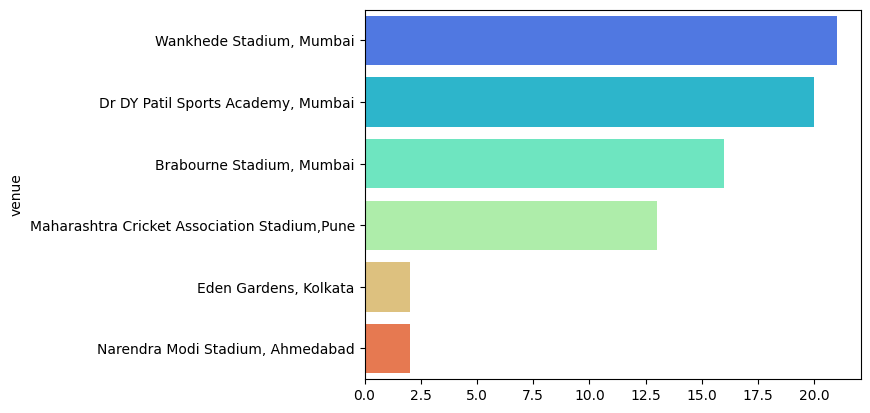

In [157]:
sns.barplot(y=venu_cou.index,x=venu_cou.values,palette='rainbow')

## Custom Questions & Insights

In [174]:
# Q1: Who won the highest margin by runs
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]
# df.nlargest(1,'margin')[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


In [189]:
# Q2: which player had the highest individual Score? 

df.nlargest(1,'highscore')[['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [194]:
# Q3: Which bowler has the best bowling figures ?
# Highest Wicket taker

# df.nlargest(1,'Highest_wic')[['best_bowling','Highest_wic']] # It is not useful when we have same wicket taker
df[df['Highest_wic']==df['Highest_wic'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
